In [35]:
import os  
import operator
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from typing import TypedDict, Annotated
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END

In [36]:
load_dotenv()
llm = init_chat_model(model="gemini-2.5-flash-lite", model_provider="google_genai", api_key = os.getenv("GEMINI_API_KEY"))

### **define graph state**

In [37]:
class State(TypedDict):
    question: str
    answer: str  
    context: Annotated[list[str], operator.add]

### **define nodes**

In [38]:
def web_search(state: State):
    """ Retrieve docs from web search """
    tavily_search = TavilySearchResults(max_results=3)
    search_docs = tavily_search(state['question'])
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


def search_wikipedia(state):
    """ Retrieve docs from wikipedia """

    # Search
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


def generate_answer(state):
    """ Node to answer question """
    context = state['context']
    question = state['question']

    # Template 
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question,context=context)
    
    # Answer
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question")])
    
    # Append it to state
    return {"answer":answer}


### **Build Graph**

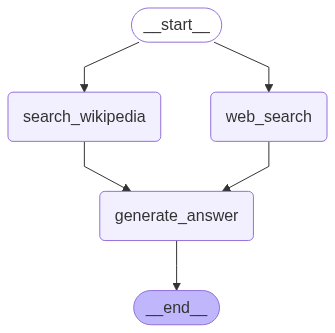

In [39]:
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("web_search", web_search)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow 
builder.add_edge(START, "web_search")
builder.add_edge(START, "search_wikipedia")
builder.add_edge("web_search", "generate_answer")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

graph


In [41]:
from IPython.display import Markdown

result = graph.invoke({"question": "How were Nvidia's Q2 2024 earnings"})
Markdown(result['answer'].content)

In the second quarter of fiscal year 2025, NVIDIA reported a record revenue of $30.0 billion. This represents a 15% increase from the previous quarter and a substantial 122% increase compared to the same period in the prior year. The company's Data Center segment also saw record quarterly revenue, reaching $26.3 billion, which is up 16% from the prior quarter and 154% from a year ago.